# 04 — Avaliação e interpretação

**Dimensão 6 da rubrica — 20 pontos.**

## Navegação
- [1. Métricas no conjunto de teste](#aval-metricas)
- [2. Matriz de confusão](#aval-matriz)
- [3. Importância das variáveis](#aval-importancia)
- [4. Implicações práticas](#aval-implicacoes)
- [5. Limitações e próximos passos](#aval-limitacoes)

A avaliação prioriza evitar que bons pagadores sejam classificados como maus pagadores e também evidencia quantos maus pagadores não são identificados. Os resultados e limitações não presumem aplicação operacional.

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib 

RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset.csv"          
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            

pd.set_option("display.max_columns", None)

# Importando os dados e o modelo da pasta processed
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze() # squeeze transforma DataFrame em Series
rf_model = joblib.load(PROCESSED / "modelo_rf_vencedor.pkl")

print("Modelo e dados importados com sucesso para o Notebook 04!")

Modelo e dados importados com sucesso para o Notebook 04!


<a id="aval-metricas"></a>
## 1. Métricas no conjunto de teste

O código anterior carrega a partição de teste e o pipeline salvos durante a modelagem. A avaliação considera o limiar padrão de `predict()`. Como a prioridade é evitar classificar bons pagadores (classe 0) como maus (classe 1), serão destacados o recall/especificidade da classe 0 e a taxa de falsos positivos. Também serão reportados o recall da classe 1, a precisão, o F1-score e a ROC-AUC. A acurácia não deve ser interpretada isoladamente devido ao forte desbalanceamento.

In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
)

# Fazendo as previsões na base de teste
y_pred_final = rf_model.predict(X_test)
y_proba_final = rf_model.predict_proba(X_test)[:, 1]

# Exibindo o Relatório de Classificação
print("--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---")
print(classification_report(y_test, y_pred_final, labels=[0, 1], digits=4, zero_division=0))

# Métricas da matriz: linhas = classe real [0, 1], colunas = classe prevista [0, 1].
matriz_confusao = confusion_matrix(y_test, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = matriz_confusao.ravel()
recall_bons_pagadores = tn / (tn + fp)
taxa_falsos_positivos = fp / (tn + fp)
recall_maus_pagadores = tp / (tp + fn)

print("\nMatriz de confusão (linhas=real, colunas=previsto):")
print(matriz_confusao)
print(f"\nRecall/especificidade dos bons pagadores (classe 0): {recall_bons_pagadores:.4f}")
print(f"Taxa de bons pagadores classificados como maus (falsos positivos): {taxa_falsos_positivos:.4f}")
print(f"Recall dos maus pagadores (classe 1): {recall_maus_pagadores:.4f}")

# Exibindo o ROC-AUC Final
roc_auc_final = roc_auc_score(y_test, y_proba_final)
print(f"\nROC-AUC Score Final: {roc_auc_final:.4f}")

--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---
              precision    recall  f1-score   support

           0     0.9878    0.9719    0.9798     10753
           1     0.1564    0.3027    0.2063       185

    accuracy                         0.9606     10938
   macro avg     0.5721    0.6373    0.5930     10938
weighted avg     0.9737    0.9606    0.9667     10938


Matriz de confusão (linhas=real, colunas=previsto):
[[10451   302]
 [  129    56]]

Recall/especificidade dos bons pagadores (classe 0): 0.9719
Taxa de bons pagadores classificados como maus (falsos positivos): 0.0281
Recall dos maus pagadores (classe 1): 0.3027

ROC-AUC Score Final: 0.6681


### 1.1 Interpretação das métricas

A saída contém 10.938 registros de teste: 10.753 da classe 0 e 185 da classe 1. O Random Forest apresenta acurácia de 0,9606 e ROC-AUC de 0,6681. Para a classe 1, a precisão é 0,1564, o recall é 0,3027 e o F1-score é 0,2063. Para a prioridade definida, importa também a classe 0: a especificidade/recall é 0,9719, isto é, 97,19% dos bons pagadores são reconhecidos; a taxa de falsos positivos é 0,0281, ou 2,81%.

O recall mede a fração dos registros reais de uma classe que o modelo identifica. A precisão da classe 1 mede, entre os casos previstos como maus pagadores, quantos são realmente da classe 1. O F1-score é a média harmônica entre precisão e recall da classe indicada. A acurácia é a fração de previsões corretas no total e pode parecer alta mesmo quando a classe rara é mal identificada. A ROC-AUC avalia a ordenação das classes em vários limiares, mas não determina sozinha um limiar de decisão adequado. Os custos financeiros dos falsos positivos e falsos negativos não foram quantificados.

<a id="aval-matriz"></a>
## 2. Matriz de confusão

A matriz apresenta as contagens de verdadeiros negativos, falsos positivos, falsos negativos e verdadeiros positivos no conjunto de teste. As linhas representam a classe real e as colunas, a classe prevista. Com a prioridade de evitar rejeitar bons pagadores, o falso positivo (classe real 0 prevista como 1) é o erro prioritário; os falsos negativos (classe real 1 prevista como 0) continuam importantes porque são maus pagadores não identificados. Interpretar as previsões como aprovações ou recusas dependeria de uma política de decisão não avaliada neste trabalho.

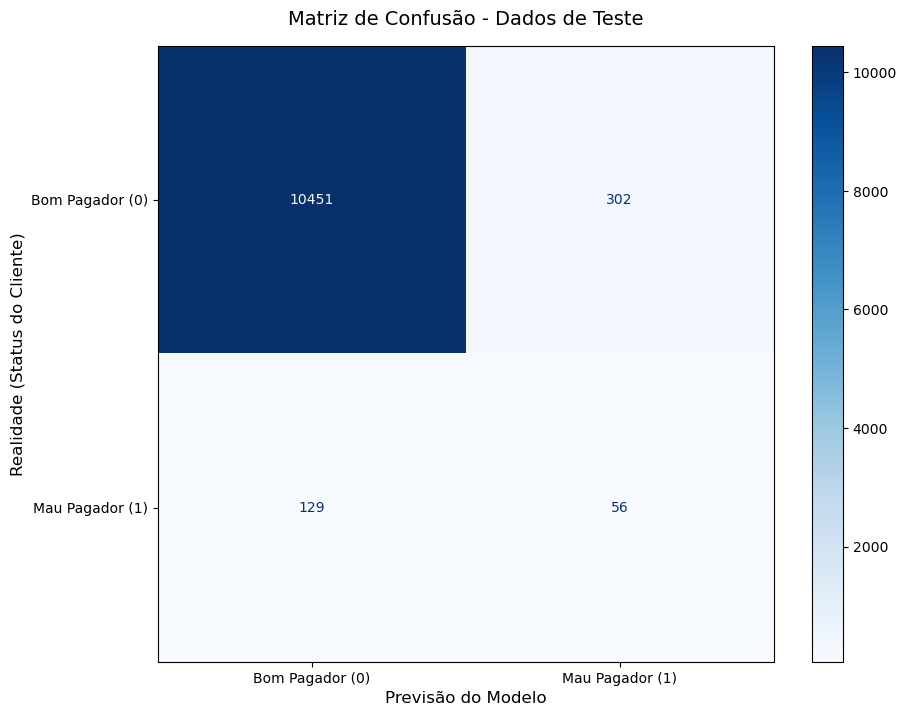

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Criando a figura para melhor visualização
fig, ax = plt.subplots(figsize=(10, 8))

# Gerando e plotando a Matriz de Confusão
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, 
    X_test, 
    y_test, 
    display_labels=['Bom Pagador (0)', 'Mau Pagador (1)'],
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)

# Alterando os rótulos dos eixos para português
ax.set_ylabel('Realidade (Status do Cliente)', fontsize=12)
ax.set_xlabel('Previsão do Modelo', fontsize=12)

plt.title('Matriz de Confusão - Dados de Teste', pad=15, fontsize=14)
plt.grid(False) # Remove as linhas de grade
plt.show()

**Leitura dos resultados:** a matriz apresenta 10.451 verdadeiros negativos (97,19% dos 10.753 clientes reais da classe 0), 302 falsos positivos (2,81% da classe 0), 129 falsos negativos (69,73% dos 185 clientes reais da classe 1) e 56 verdadeiros positivos (30,27% da classe 1). Assim, o modelo reconhece corretamente a maioria dos bons pagadores, mas deixa de identificar 69,73% dos maus pagadores. Os percentuais são calculados dentro de cada classe real, não sobre o total do conjunto de teste. As contagens não quantificam impactos financeiros nem o resultado de uma política real de concessão.

<a id="aval-importancia"></a>
## 3. Importância das variáveis

O Random Forest faz as previsões com o modelo treinado e o limiar padrão de `predict()`. O recall não produz as classificações: é uma métrica calculada depois para avaliar os resultados. No conjunto de teste, o recall foi 97,19% para bons pagadores (classe 0) e 30,27% para maus pagadores (classe 1).

Para analisar a importância, os pesquisadores permutam cada coluna de entrada no conjunto de teste e medem a mudança no recall dos bons pagadores (classe 0). A tabela apresenta o ranking de todas as colunas avaliadas, da maior à menor queda média dessa métrica; o gráfico destaca somente as 10 primeiras para facilitar a visualização. Como as variáveis categóricas foram transformadas em colunas indicadoras, o ranking trata cada coluna codificada separadamente. A ordem é relativa a este modelo, a este conjunto de teste e a esta métrica: não há um limite estatístico definido para separar variáveis importantes de irrelevantes. A permutação é uma análise global, pode repartir importância entre variáveis correlacionadas e não demonstra causalidade.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, recall_score

# A pontuação corresponde à prioridade: preservar bons pagadores (classe 0).
resultado_permutacao = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring=make_scorer(recall_score, pos_label=0),
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

modelo_rf = rf_model.named_steps['model']
traducao_profissoes = {
    'Cleaning_staff': 'Serviços de limpeza',
    'Cooking_staff': 'Serviços de cozinha',
    'Core_staff': 'Equipe principal',
    'Drivers': 'Motoristas',
    'HR_staff': 'Recursos humanos',
    'High_skill_tech_staff': 'Profissionais de tecnologia qualificados',
    'IT_staff': 'Profissionais de tecnologia da informação',
    'Laborers': 'Trabalhadores braçais',
    'Low-skill_Laborers': 'Trabalhadores não qualificados',
    'Managers': 'Gestores',
    'Medicine_staff': 'Profissionais da saúde',
    'Outros': 'Outras profissões',
    'Private_service_staff': 'Prestadores de serviços particulares',
    'Realty_agents': 'Corretores de imóveis',
    'Sales_staff': 'Profissionais de vendas',
    'Secretaries': 'Secretários',
    'Security_staff': 'Profissionais de segurança',
    'Waiters/barmen_staff': 'Garçons e atendentes de bar'
}
prefixos_variaveis = {
    'TIPO_RENDA_': 'Tipo de renda',
    'ESCOLARIDADE_': 'Escolaridade',
    'ESTADO_CIVIL_': 'Estado civil',
    'TIPO_HABITACAO_': 'Tipo de habitação',
    'PROFISSAO_': 'Profissão'
}
nomes_variaveis = {
    'FLAG_OWN_CAR': 'Possui carro',
    'FLAG_OWN_REALTY': 'Possui imóvel',
    'CNT_CHILDREN': 'Quantidade de filhos',
    'RENDA_TOTAL': 'Renda total',
    'TEM_TELEMÓVEL': 'Tem_Celular',
    'TEM_TELEMOVEL': 'Tem_Celular',
    'TEM_TELEFONE_TRABALHO': 'Tem telefone de trabalho',
    'TEM_TELEFONE_FIXO': 'Tem telefone fixo',
    'TEM_EMAIL': 'Tem e-mail',
    'QTD_MEMBROS_FAMILIA': 'Quantidade de membros da família',
    'IDADE_ANOS': 'Idade (anos)',
    'TEMPO_EMPREGO_ANOS': 'Tempo de emprego (anos)',
    'RENDA_PER_CAPITA': 'Renda per capita',
    'GENERO_MASCULINO': 'Gênero masculino'
}

def traduzir_nome_variavel(nome):
    if nome in nomes_variaveis:
        return nomes_variaveis[nome]
    for prefixo, nome_prefixo in prefixos_variaveis.items():
        if nome.startswith(prefixo):
            categoria = nome[len(prefixo):]
            if prefixo == 'PROFISSAO_':
                categoria = traducao_profissoes.get(categoria, categoria.replace('_', ' '))
            else:
                categoria = categoria.replace('_', ' ').capitalize()
            return f'{nome_prefixo}: {categoria}'
    return nome.replace('_', ' ').capitalize()

df_importancias = pd.DataFrame({
    'Variável': X_test.columns,
    'Queda média no recall classe 0': resultado_permutacao.importances_mean,
    'Desvio padrão da queda': resultado_permutacao.importances_std,
    'Importância por impureza (RF)': modelo_rf.feature_importances_
}).sort_values('Queda média no recall classe 0', ascending=False, kind='stable')

df_importancias_exibicao = df_importancias.copy()
df_importancias_exibicao['Variável'] = df_importancias_exibicao['Variável'].map(
    traduzir_nome_variavel
)
df_importancias_exibicao.insert(
    0, 'Posição no ranking', range(1, len(df_importancias_exibicao) + 1)
)
display(df_importancias_exibicao.reset_index(drop=True).style.format({
    'Queda média no recall classe 0': '{:.6f}',
    'Desvio padrão da queda': '{:.6f}',
    'Importância por impureza (RF)': '{:.6f}'
}))

top_10_importancias = df_importancias.head(10).copy()
top_10_importancias['Variável'] = top_10_importancias['Variável'].map(
    traduzir_nome_variavel
)
top_10_importancias = top_10_importancias.sort_values(
    'Queda média no recall classe 0', ascending=True
)
fig, ax = plt.subplots(figsize=(14, 8))
ax = sns.barplot(
    x='Queda média no recall classe 0',
    y='Variável',
    data=top_10_importancias,
    color='#3498db',
    ax=ax
)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=5, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variáveis mais relevantes para reconhecer bons pagadores', pad=15, fontsize=14)
ax.set_xlabel('Queda média do recall da classe 0 após permutação', fontsize=11)
ax.set_ylabel('Variável', fontsize=11)
ax.margins(x=0.2)
fig.subplots_adjust(left=0.42, right=0.98)
plt.show()

**Classificação e avaliação:** o Random Forest usa o modelo treinado e o limiar padrão de `predict()` para prever a classe 0 ou 1 de cada cliente. O recall é calculado depois para avaliar essas previsões; ele não é o mecanismo que classifica os clientes. No conjunto de teste, o recall foi 97,19% para bons pagadores (classe 0) e 30,27% para maus pagadores (classe 1).

**Como avaliamos a importância:** o embaralhamento testa a importância das variáveis e não faz parte do treinamento. Para cada coluna, os pesquisadores trocam aleatoriamente seus valores entre os clientes do conjunto de teste, mantendo as outras colunas, os valores reais de `TARGET` e o modelo treinado sem alterações. Depois, calculam novamente o recall dos bons pagadores. Repetem essa operação 10 vezes por coluna e calculam a queda média do recall. Os dados originais e o modelo permanecem inalterados.

**Como ler a tabela e o gráfico:** a tabela ordena todas as colunas avaliadas pela queda média no recall da classe 0; o gráfico mostra apenas as 10 primeiras. Uma queda positiva indica que o recall diminuiu após o embaralhamento, sugerindo maior dependência do modelo naquela coluna para reconhecer bons pagadores. Um valor negativo indica que o recall ficou um pouco maior naquela avaliação. Valores negativos podem resultar de variação aleatória, redundância ou ruído; não indicam uma relação protetiva nem causal. Valores próximos de zero indicam pouca mudança mensurável neste teste.

O ranking é uma ordenação relativa, não uma classificação definitiva entre variáveis importantes e sem importância. Não há um valor de corte definido para essa separação; portanto, uma posição baixa ou uma queda próxima de zero não prova que a variável seja irrelevante. Como as categorias foram codificadas em colunas indicadoras separadas, embaralhar uma coluna por vez pode formar combinações de categorias que não ocorrem nos dados originais; os resultados devem ser interpretados como uma estimativa global, não como um efeito isolado real. O desvio padrão mostra a variação entre as permutações. A importância por impureza é uma medida interna das árvores e pode favorecer variáveis contínuas ou com muitas possibilidades de corte; por isso, não deve ser usada sozinha para definir relevância.

A tabela permite verificar numericamente se `TEM_TELEFONE_FIXO` realmente contribui para o objetivo avaliado: sua presença entre as maiores importâncias por impureza não basta para chamá-la de importante se a permutação quase não reduzir o recall dos bons pagadores. Variáveis correlacionadas podem mascarar a contribuição umas das outras. Nenhuma dessas importâncias estabelece causalidade ou explica individualmente uma previsão.

<a id="aval-implicacoes"></a>
## 4. Implicações práticas

No conjunto de teste e no limiar padrão, o Random Forest identificou corretamente 10.451 dos 10.753 bons pagadores e classificou incorretamente 302 como maus pagadores: recall/especificidade da classe 0 de 97,19% e taxa de falsos positivos de 2,81%. Também identificou 56 dos 185 maus pagadores, deixando 129 sem identificação (recall da classe 1 de 30,27%). Portanto, atende melhor à prioridade de evitar classificar bons pagadores como maus entre os modelos avaliados, mas não identifica a maioria dos maus pagadores.

Esses resultados não bastam para recomendar o uso do modelo numa política de concessão de crédito nem para declarar o modelo globalmente bom: não há limite mínimo de aceitação nem custos de falsos positivos e falsos negativos quantificados. A avaliação de limiares deve usar dados de validação e custos definidos com as áreas responsáveis; essa análise ainda não foi realizada.

Antes de qualquer uso operacional, seriam necessárias validações temporais, análise de vieses, calibração, definição de governança e monitoramento. As métricas atuais não justificam aprovação automática nem campanhas automatizadas.

<a id="aval-limitacoes"></a>
## 5. Limitações e próximos passos

O alvo é retrospectivo: um cliente recebe classe 1 se apresentou atraso grave em qualquer momento do histórico observado, cujo período varia entre clientes. Clientes observados por mais tempo tiveram maior oportunidade de registrar o evento; o rótulo não corresponde a um horizonte futuro fixo.

A classe positiva representa aproximadamente 1,69% da população de modelagem, limitando a quantidade de exemplos disponíveis para aprender padrões raros. As features concentram-se no cadastro e não incluem uma janela recente padronizada de comportamento de crédito. Como próximos passos, podem ser avaliados um alvo temporal explícito, dados comportamentais recentes, limiares orientados a custos, validação fora do tempo, comparação com outros modelos, análise de vieses e monitoramento de desempenho.